In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
if None != os.getenv('NERSC_HOST'):
    import matplotlib.font_manager as font_manager
    font_manager.fontManager.addfont('/global/cfs/cdirs/lz/physics/WS/SR1/msttcorefonts/Times_New_Roman.ttf')

#import matplotlib as mpl
import matplotlib
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'

plt.style.use('/global/cfs/cdirs/lz/users/haselsco/sr3/LZStyle/SetLZStyle.mplstyle')

from multihist import Hist1d

from scipy.interpolate import interp1d


%matplotlib inline

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx, array[idx]

In [2]:
#x1tmig = np.loadtxt('/global/cfs/cdirs/lz/users/haselsco/TESSERACT_Limits/snowmass2021-wp-cf1-neutrinofloor/data/published/SI/XENON1T-Migdal.txt')

def extrapolate(data, mass=1e6):
    m0, s0 = data[-1]
    return np.concatenate([data,[[mass, s0*mass/m0]]], axis=0)

def minbound(curves, masses=None):
    if masses is None:
        masses = np.logspace(-2, 4, 200)
    result = np.array([np.nan]*len(masses))
    for curve in curves:
        if curve[-1][0] < masses[-1]:
            curve = extrapolate(curve, masses[-1])
        yinterp = 10**(interp1d(*(np.log10(curve).T), bounds_error=False)(np.log10(masses)))
        #yinterp = interp1d(*(curve.T), bounds_error=False)(masses)
        result = np.nanmin([result, yinterp], axis=0)
    return np.array([masses, result]).T

def load_and_plot_existing(ax, leg=True,lw=0.5,leg_params=None):
    curves_dir = 'ExistingLimits/'
    m_lim, x_lim = np.loadtxt(curves_dir + 'CRESST_III_2019.txt').transpose()
    l1, = ax.plot(m_lim, x_lim, '-', color='#CFC0E5', lw=lw, label='CRESST 2019')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'DAMIC_2020.txt').transpose()
    #l2, = ax.plot(m_lim, x_lim, '--', color='#CE977A', lw=lw, label='DAMIC 2020')

    m_lim, x_lim = np.loadtxt(curves_dir + 'CRESST_III_2024.txt').transpose()
    l2, = ax.plot(m_lim, x_lim, '-', color='#CE977A', lw=lw, label='CRESST 2024')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'Cosmic_Rays_2018.txt').transpose()
    #ax.plot(m_lim, x_lim, '--', color='#C9C0E5', lw=2, label='Cosmic Rays 2018')
    
    m_lim, x_lim = np.loadtxt(curves_dir + 'CDMSlite_2019.txt').transpose()
    l3, = ax.plot(m_lim, x_lim, '-', color='#a4dbed', lw=lw, label='CDMSlite 2019')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'CRESST_Surface_2017.txt').transpose()
    #l5, = ax.plot(m_lim, x_lim, '--', color='#C3B02F', lw=lw, label='nu-cleus 2017')
    
    m_lim, x_lim = np.loadtxt(curves_dir + 'XENON1T_S2Only_2019.txt').transpose()
    l6, = ax.plot(m_lim, x_lim, '-', color='#56872C', lw=lw, label='XENON1T S2-Only 2019')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'LZ_SI_2022.txt').transpose()
    #l8, = ax.plot(m_lim, x_lim, '--', color='#bcced4', lw=lw, label='LZ 2022')
    
    #m_lim, x_lim = np.loadtxt(curves_dir + 'Das_Kurinsky_2024.txt').transpose()
    #l10, = ax.plot(m_lim, x_lim, '--', color='lightgreen', lw=lw, label='Das 2024')
    
    m_lim, x_lim = np.loadtxt(curves_dir + 'TESSERACT_2025_Limit.txt').transpose()
    l11, = ax.plot(m_lim, x_lim, '-', color='tomato', lw=lw, label='TESSERACT 2025',alpha=0.7)

    # migdals
    m_lim, x_lim = np.loadtxt(curves_dir + 'Darkside50_Migdal_2023.txt').transpose()
    l9, = ax.plot(m_lim, x_lim, '--', color='#a4bd8e', lw=lw, label='DarkSide-50 2023')

    m_lim, x_lim = np.loadtxt(curves_dir + 'PandaX4T_Migdal_2023.txt').transpose()
    l5, = ax.plot(m_lim, x_lim, '--', color='darkgrey', lw=lw, label='PandaX-4T Migdal 2023') #color='#C3B02F'

    m_lim, x_lim = np.loadtxt(curves_dir + 'XENON1T_Migdal_2019.txt').transpose()
    l4, = ax.plot(m_lim, x_lim, '--', color='#CA778C', lw=lw, label='XENON1T Migdal 2019')

    m_lim, x_lim = np.loadtxt(curves_dir + 'EDELWEISS_Migdal_2019.txt').transpose()
    l7, = ax.plot(m_lim, x_lim, '--', color='#D7ADB7', lw=lw, label='EDELWEISS Migdal 2019')
    
    if leg:
        #leg1 = ax.legend(handles=[l5, l9, l1, l2, l3, l4, l6, l7, l11], **leg_params)
        leg1 = ax.legend(handles=[l1, l2, l3, l6, l11, l9, l5, l4, l7], **leg_params)
        #leg1 = ax.legend(handles=[l1, l2, l3, l6, l11], **leg_params) # no migdal
        ax.add_artist(leg1)
    
    return

In [3]:
def plotexcludedsi(ax, details=False, **kwargs):
    curves_dir = 'ExistingLimits/'
    #xs2o = np.loadtxt(curves_dir + 'XENON1T_S2Only_2019.txt')

    # curves that define the edge:
    dsmig = np.loadtxt(curves_dir + 'Darkside50_Migdal_2023.txt')
    pxmig = np.loadtxt(curves_dir + 'PandaX4T_Migdal_2023.txt')
    data = minbound([dsmig,pxmig], masses=None)#data.T[0])
    
    
    kwargs.setdefault('edgecolor', None)
    kwargs.setdefault('facecolor','#000000')
    kwargs.setdefault('alpha',0.03)
    #data = extrapolate(data, 1e5)
    ax.fill_between(*(data.T), ax.get_ylim()[1], **kwargs)
    if details:
        load_and_plot_existing(ax,leg=False,lw=1)

In [17]:
curves_dir = 'ExistingLimits/'
dsmig = np.loadtxt(curves_dir + 'Darkside50_Migdal_2023.txt')
pxmig = np.loadtxt(curves_dir + 'PandaX4T_Migdal_2023.txt')
print(np.shape(pxmig))

(74, 2)


In [4]:
# old - load result from .txt files


t_days = 10
    
d = '4-1cm2'
vol = 7.65
he_gain = 0.15
thres = 0.8e-3
energy_res_eV = 0.200

results_dir = 'results-{d:s}-{vol:0.2f}cm3-{he_gain:0.2f}gain-{thres:0.2e}keV-{energy_res_eV:0.3f}eV-{t_days:0.1f}day_var_wpart'.format(d=d, vol=vol, he_gain=he_gain, thres=thres, energy_res_eV=energy_res_eV, t_days=t_days)
print('loading from:\n{:s}'.format(results_dir))
data = {}
data['1_1'] = np.loadtxt('./{:s}/limit.txt'.format(results_dir))

## thin detectors
d = '4-1cm2-thin'
thres = 0.8e-3
energy_res_eV = 0.020
results_dir = 'results-{d:s}-{vol:0.2f}cm3-{he_gain:0.2f}gain-{thres:0.2e}keV-{energy_res_eV:0.3f}eV-{t_days:0.1f}day_var_wpart'.format(d=d, vol=vol, he_gain=he_gain, thres=thres, energy_res_eV=energy_res_eV, t_days=t_days)
print('loading from:\n{:s}'.format(results_dir))
data['2_1'] = np.loadtxt('./{:s}/limit.txt'.format(results_dir))

## thin detectors
d = '4-1cm2-thin-0.1xLEE'
thres = 0.6e-3
energy_res_eV = 0.020
results_dir = 'results-{d:s}-{vol:0.2f}cm3-{he_gain:0.2f}gain-{thres:0.2e}keV-{energy_res_eV:0.3f}eV-{t_days:0.1f}day_var_wpart'.format(d=d, vol=vol, he_gain=he_gain, thres=thres, energy_res_eV=energy_res_eV, t_days=t_days)
print('loading from:\n{:s}'.format(results_dir))
data['3_1'] = np.loadtxt('./{:s}/limit.txt'.format(results_dir))

mass_det = vol*0.14

print('\ndone.')

loading from:
results-4-1cm2-7.65cm3-0.15gain-8.00e-04keV-0.200eV-10.0day_var_wpart
loading from:
results-4-1cm2-thin-7.65cm3-0.15gain-8.00e-04keV-0.020eV-10.0day_var_wpart
loading from:
results-4-1cm2-thin-0.1xLEE-7.65cm3-0.15gain-6.00e-04keV-0.020eV-10.0day_var_wpart

done.


In [4]:
# pick exposure, load all detectors and thresholds

t_days = 10

vol = 7.65
he_gain = 0.15


detectors = ['4-1cm2','4-1cm2-thin','4-1cm2-thin-0.1xLEE']
thresholds = np.array([0.6,0.7,0.8])*1e-3

hdict = {}

for i,d in enumerate(detectors):
    print('')
    hdict[d+str(i)] = load_template(detector=d,window='var',part='wpart',thres=thresholds[i])#per_device_threshold)


d = '4-1cm2'

thres = 0.8e-3
energy_res_eV = 0.200

results_dir = 'results-{d:s}-{vol:0.2f}cm3-{he_gain:0.2f}gain-{thres:0.2e}keV-{energy_res_eV:0.3f}eV-{t_days:0.1f}day_var_wpart'.format(d=d, vol=vol, he_gain=he_gain, thres=thres, energy_res_eV=energy_res_eV, t_days=t_days)
print('loading from:\n{:s}'.format(results_dir))
data = {}
data['1_1'] = np.loadtxt('./{:s}/limit.txt'.format(results_dir))

## thin detectors
d = '4-1cm2-thin'
thres = 0.8e-3
energy_res_eV = 0.020
results_dir = 'results-{d:s}-{vol:0.2f}cm3-{he_gain:0.2f}gain-{thres:0.2e}keV-{energy_res_eV:0.3f}eV-{t_days:0.1f}day_var_wpart'.format(d=d, vol=vol, he_gain=he_gain, thres=thres, energy_res_eV=energy_res_eV, t_days=t_days)
print('loading from:\n{:s}'.format(results_dir))
data['2_1'] = np.loadtxt('./{:s}/limit.txt'.format(results_dir))

## thin detectors
d = '4-1cm2-thin-0.1xLEE'
thres = 0.6e-3
energy_res_eV = 0.020
results_dir = 'results-{d:s}-{vol:0.2f}cm3-{he_gain:0.2f}gain-{thres:0.2e}keV-{energy_res_eV:0.3f}eV-{t_days:0.1f}day_var_wpart'.format(d=d, vol=vol, he_gain=he_gain, thres=thres, energy_res_eV=energy_res_eV, t_days=t_days)
print('loading from:\n{:s}'.format(results_dir))
data['3_1'] = np.loadtxt('./{:s}/limit.txt'.format(results_dir))

mass_det = vol*0.14

print('\ndone.')

NameError: name 'load_template' is not defined

In [29]:
# pick exposure, load all detectors and thresholds

t_days = 100

vol = 7.65
mass_det = vol*0.14
he_gain = 0.15

data = {}

# baseline detector:
d = '4-1cm2'
energy_res_eV = 0.200
thresholds = np.array([0.7,0.8,1.0])*1e-3
#thresholds = np.array([0.8,1.0])*1e-3

for i, thres in enumerate(thresholds):
    results_dir = 'results-{d:s}-{vol:0.2f}cm3-{he_gain:0.2f}gain-{thres:0.2e}keV-{energy_res_eV:0.3f}eV-{t_days:0.1f}day_var_wpart'.format(d=d, vol=vol, he_gain=he_gain, thres=thres, energy_res_eV=energy_res_eV, t_days=t_days)
    print('loading from:\n{:s}'.format(results_dir))
    data['0_'+str(i)] = np.loadtxt('./{:s}/limit.txt'.format(results_dir))

## thin detectors
d = '4-1cm2-thin'
energy_res_eV = 0.020
#thresholds = np.array([0.6,0.7,0.8])*1e-3
thresholds = np.array([0.6,0.7,0.8])*1e-3

for i, thres in enumerate(thresholds):
    results_dir = 'results-{d:s}-{vol:0.2f}cm3-{he_gain:0.2f}gain-{thres:0.2e}keV-{energy_res_eV:0.3f}eV-{t_days:0.1f}day_var_wpart'.format(d=d, vol=vol, he_gain=he_gain, thres=thres, energy_res_eV=energy_res_eV, t_days=t_days)
    print('loading from:\n{:s}'.format(results_dir))
    data['1_'+str(i)] = np.loadtxt('./{:s}/limit.txt'.format(results_dir))

## thin detectors
d = '4-1cm2-thin-0.1xLEE'
energy_res_eV = 0.020
#thresholds = np.array([0.6,0.7,0.8])*1e-3
thresholds = np.array([0.6,0.7,0.8])*1e-3

for i, thres in enumerate(thresholds):
    results_dir = 'results-{d:s}-{vol:0.2f}cm3-{he_gain:0.2f}gain-{thres:0.2e}keV-{energy_res_eV:0.3f}eV-{t_days:0.1f}day_var_wpart'.format(d=d, vol=vol, he_gain=he_gain, thres=thres, energy_res_eV=energy_res_eV, t_days=t_days)
    print('loading from:\n{:s}'.format(results_dir))
    data['2_'+str(i)] = np.loadtxt('./{:s}/limit.txt'.format(results_dir))


print('\ndone.')

loading from:
results-4-1cm2-7.65cm3-0.15gain-7.00e-04keV-0.200eV-100.0day_var_wpart
loading from:
results-4-1cm2-7.65cm3-0.15gain-8.00e-04keV-0.200eV-100.0day_var_wpart
loading from:
results-4-1cm2-7.65cm3-0.15gain-1.00e-03keV-0.200eV-100.0day_var_wpart
loading from:
results-4-1cm2-thin-7.65cm3-0.15gain-6.00e-04keV-0.020eV-100.0day_var_wpart
loading from:
results-4-1cm2-thin-7.65cm3-0.15gain-7.00e-04keV-0.020eV-100.0day_var_wpart
loading from:
results-4-1cm2-thin-7.65cm3-0.15gain-8.00e-04keV-0.020eV-100.0day_var_wpart
loading from:
results-4-1cm2-thin-0.1xLEE-7.65cm3-0.15gain-6.00e-04keV-0.020eV-100.0day_var_wpart
loading from:
results-4-1cm2-thin-0.1xLEE-7.65cm3-0.15gain-7.00e-04keV-0.020eV-100.0day_var_wpart
loading from:
results-4-1cm2-thin-0.1xLEE-7.65cm3-0.15gain-8.00e-04keV-0.020eV-100.0day_var_wpart

done.


/tmp/ipykernel_1936900/2682253033.py:16: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)


Text(0.014, 2e-33, 'HeRALD - 1.1 g \n$2\\times2$ array \n100 livedays')

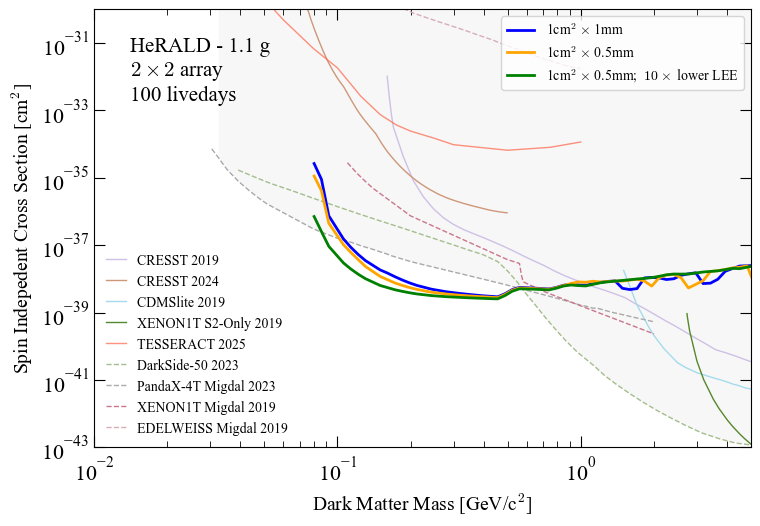

In [30]:
# plot limits

acceptance_cut = 0.0001

fig, ax = plt.subplots(figsize=(9, 6))
#plotexcludedsi(ax, details=False)
#load_and_plot_existing(ax,leg=False,lw=1.5,leg_params={'loc':'upper right','frameon':False,'handlelength':1.5 } )

plotexcludedsi(ax, details=False)
    #leg_params = {'loc':'upper right',
    #              'frameon':True,
    #              'handlelength':1.5,
    #              'fontsize':9,
    #              'ncol':3 }
leg_params = {'loc':'lower left',
                  'frameon':False,
                  'handlelength':1.4,
                  'fontsize':10,
                  'ncol':1 }
load_and_plot_existing(ax,leg=True,lw=1,leg_params=leg_params )

leg_hands = []

#lab = '{:0.2f} eV thres./sensor'.format(thres*1e3)

detectors = ['4-1cm2','4-1cm2-thin','4-1cm2-thin-0.1xLEE']

### baseline
i=0 # selects detector
#thresholds = np.array([0.7,0.8,1.0])*1e-3
thresholds = np.array([0.7,0.8,1.0])*1e-3
bounding_lims = []
for j, thres in enumerate(thresholds):
    acc_mask = data['{:d}_{:d}'.format(i,j)][:,2]>acceptance_cut
    masses = data['{:d}_{:d}'.format(i,j)][:,0][acc_mask]
    sigs = data['{:d}_{:d}'.format(i,j)][:,1][acc_mask]
    bounding_lims.append(np.column_stack((masses,sigs)))
    
    lab = detectors[i]+'; {:0.1f} eV/sensor'.format(thres*1000)
    
    #lh, = plt.plot(masses,sigs,label=lab,lw=2)#,color='blue')
    #leg_hands.append(lh)

bdata = minbound([bounding_lims[0],bounding_lims[1],bounding_lims[2]], masses=None)
lh, = plt.plot(*(bdata.T), color='blue')
leg_hands.append(lh)


### thin detector
i=1 # selects detector
thresholds = np.array([0.6,0.7,0.8])*1e-3
bounding_lims = []
for j, thres in enumerate(thresholds):
    acc_mask = data['{:d}_{:d}'.format(i,j)][:,2]>acceptance_cut
    masses = data['{:d}_{:d}'.format(i,j)][:,0][acc_mask]
    sigs = data['{:d}_{:d}'.format(i,j)][:,1][acc_mask]
    bounding_lims.append(np.column_stack((masses,sigs)))
    
    lab = detectors[i]+'; {:0.1f} eV/sensor'.format(thres*1000)
    
    #lh, = plt.plot(masses,sigs,label=lab,lw=2)#,color='blue')
    #leg_hands.append(lh)

bdata = minbound([bounding_lims[0],bounding_lims[1],bounding_lims[2]], masses=None)
lh, = plt.plot(*(bdata.T), color='orange')
leg_hands.append(lh)


### thin+10x lower LEE detector
i=2 # selects detector
thresholds = np.array([0.6,0.7,0.8])*1e-3
bounding_lims = []
for j, thres in enumerate(thresholds):
    acc_mask = data['{:d}_{:d}'.format(i,j)][:,2]>acceptance_cut
    masses = data['{:d}_{:d}'.format(i,j)][:,0][acc_mask]
    sigs = data['{:d}_{:d}'.format(i,j)][:,1][acc_mask]
    bounding_lims.append(np.column_stack((masses,sigs)))
    
    lab = detectors[i]+'; {:0.1f} eV/sensor'.format(thres*1000)
    
    #lh, = plt.plot(masses,sigs,label=lab,lw=2)#,color='blue')
    #leg_hands.append(lh)

bdata = minbound([bounding_lims[0],bounding_lims[1],bounding_lims[2]], masses=None)
lh, = plt.plot(*(bdata.T), color='green')
leg_hands.append(lh)



#leg_labels = ['1cm2x1mm', 
#              '1cm2x0.5mm', 
#              '1cm2x0.5mm, 10x lower LEE'] 

leg_labels = [r'1cm$^2$ $\times$ 1mm',
          r'1cm$^2$ $\times$ 0.5mm',
          r'1cm$^2$ $\times$ 0.5mm;  $10\times$ lower LEE']

#ax.set_title('{:0.1f} g LHe; {:0.0f} days; {:0.1f} g-day'.format(mass_det*1e3,times[i],mass_det*1e3*times[i]))
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-43, 1e-30)
ax.set_xlim(0.01, 5)
ax.set_xlabel("Dark Matter Mass [GeV/c$^2$]", fontsize=14)
ax.set_ylabel("Spin Indepedent Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

#ax.legend(handles=leg_hands,labels=leg_labels,loc='upper right',frameon=True,ncol=1) #,title='{:d} Devices'.format(n_devices)) #bbox_to_anchor=(0.5, 1.05)

ax.legend(handles=leg_hands,labels=leg_labels,loc='upper right',frameon=True,ncol=1)
              
ax.text(1.4e-2,2e-33,'HeRALD - {:0.1f} g \n'.format(mass_det)+r'$2\times2$'+' array \n'+'{:0.0f} livedays'.format(t_days),fontsize=15)




In [20]:
#data['2_1']

In [6]:
# load result from .txt files


t_days = 10
    
d = '4-1cm2'
vol = 7.65
he_gain = 0.15
thres = 0.8e-3
energy_res_eV = 0.200

results_dir = 'results-{d:s}-{vol:0.2f}cm3-{he_gain:0.2f}gain-{thres:0.2e}keV-{energy_res_eV:0.3f}eV-{w:0.0e}s-{t_days:0.1f}day_var_wpart'.format(d=d, vol=vol, he_gain=he_gain, thres=thres, energy_res_eV=energy_res_eV, t_days=t_days)

print('loading from:\n{:s}'.format(results_dir))
data = {}
data['1_1'] = np.loadtxt('./{:s}/limit.txt'.format(results_dir))

#t_days = 100
#results_dir = 'results-{d:s}-{vol:0.2f}cm3-{he_gain:0.2f}gain-{thres:0.2e}keV-{energy_res_eV:0.3f}eV-{w:0.0e}s-{t_days:0.1f}day'.format(d=d, vol=vol, he_gain=he_gain, thres=thres, energy_res_eV=energy_res_eV, w=w, t_days=t_days)
#data['1_2'] = np.loadtxt('./{:s}/limit.txt'.format(results_dir))

# 'lil guy
t_days = 10
d = '4-0.5cm2'
vol = 0.92
he_gain = 0.15
thres = 0.4e-3
energy_res_eV = 0.200
w = 100e-6
results_dir = 'results-{d:s}-{vol:0.2f}cm3-{he_gain:0.2f}gain-{thres:0.2e}keV-{energy_res_eV:0.3f}eV-{w:0.0e}s-{t_days:0.1f}day'.format(d=d, vol=vol, he_gain=he_gain, thres=thres, energy_res_eV=energy_res_eV, w=w, t_days=t_days)
data['2_1'] = np.loadtxt('./{:s}/limit.txt'.format(results_dir))

# medium w/16 sensors
t_days = 10
d = '16-0.5cm2'
vol = 7.65
he_gain = 0.15
thres = 0.4e-3
energy_res_eV = 0.200
w = 100e-6
results_dir = 'results-{d:s}-{vol:0.2f}cm3-{he_gain:0.2f}gain-{thres:0.2e}keV-{energy_res_eV:0.3f}eV-{w:0.0e}s-{t_days:0.1f}day'.format(d=d, vol=vol, he_gain=he_gain, thres=thres, energy_res_eV=energy_res_eV, w=w, t_days=t_days)
data['3_1'] = np.loadtxt('./{:s}/limit.txt'.format(results_dir))

# big boy
t_days = 10
d = '24-0.5cm2'
vol = 102
he_gain = 0.15
thres = 0.6e-3
energy_res_eV = 0.200
w = 100e-6
results_dir = 'results-{d:s}-{vol:0.2f}cm3-{he_gain:0.2f}gain-{thres:0.2e}keV-{energy_res_eV:0.3f}eV-{w:0.0e}s-{t_days:0.1f}day'.format(d=d, vol=vol, he_gain=he_gain, thres=thres, energy_res_eV=energy_res_eV, w=w, t_days=t_days)
data['4_1'] = np.loadtxt('./{:s}/limit.txt'.format(results_dir))




#for i,t in enumerate(times):
#    for j,n in enumerate(coinc):
#        data['{:d}_{:d}'.format(i,j)] = np.loadtxt('./{:s}/HeRALD_FC_{:0.0f}d_{:d}device_{:d}fold_{:0.0f}mus.txt'.format(results_dir,t,n_devices,n,window/1e-6))

loading from:
results-4-1cm2-7.65cm3-0.15gain-8.00e-04keV-0.200eV-1e-04s-10.0day


/tmp/ipykernel_779233/2682253033.py:16: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)


Text(0.014, 2e-33, 'HeRALD - 1.1 g \n$2\\times2$ array \n10 livedays')

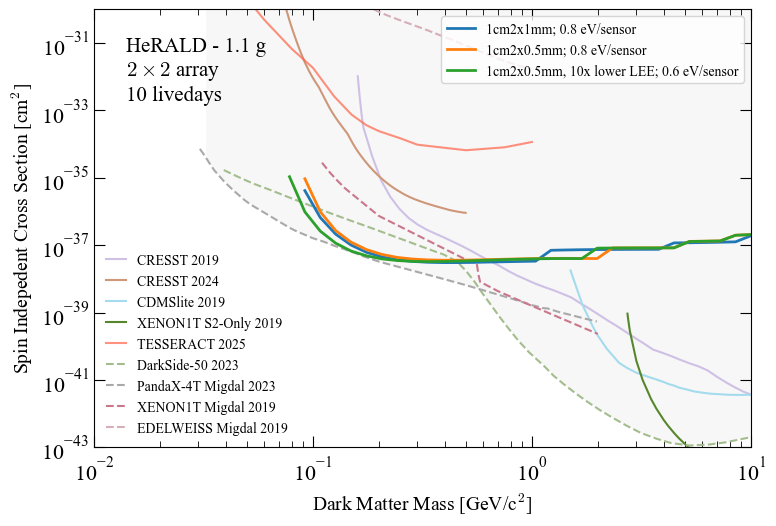

In [6]:
acceptance_cut = 0.0001

fig, ax = plt.subplots(figsize=(9, 6))
#plotexcludedsi(ax, details=False)
#load_and_plot_existing(ax,leg=False,lw=1.5,leg_params={'loc':'upper right','frameon':False,'handlelength':1.5 } )

plotexcludedsi(ax, details=False)
    #leg_params = {'loc':'upper right',
    #              'frameon':True,
    #              'handlelength':1.5,
    #              'fontsize':9,
    #              'ncol':3 }
leg_params = {'loc':'lower left',
                  'frameon':False,
                  'handlelength':1.4,
                  'fontsize':10,
                  'ncol':1 }
load_and_plot_existing(ax,leg=True,lw=1,leg_params=leg_params )

leg_hands = []

lab = '{:0.2f} eV thres./sensor'.format(thres*1e3)

j=1
for i in np.arange(1,4):
    acc_mask = data['{:d}_{:d}'.format(i,j)][:,2]>acceptance_cut
    masses = data['{:d}_{:d}'.format(i,j)][:,0][acc_mask]
    sigs = data['{:d}_{:d}'.format(i,j)][:,1][acc_mask]
    
    lh, = plt.plot(masses,sigs,label=lab,lw=2)#,color='blue')
    leg_hands.append(lh)

leg_labels = ['1cm2x1mm; 0.8 eV/sensor', 
              '1cm2x0.5mm; 0.8 eV/sensor',
              '1cm2x0.5mm, 10x lower LEE; 0.6 eV/sensor']#,
#              '0.13 g; 4 0.5cm2 sensors; 0.4 eV/sensor',
#              '1.1 g; 16 0.5cm2 sensors; 0.6 eV/sensor',
#              '14.3 g; 24 0.5cm2 sensors; 0.8 eV/sensor']

#ax.set_title('{:0.1f} g LHe; {:0.0f} days; {:0.1f} g-day'.format(mass_det*1e3,times[i],mass_det*1e3*times[i]))
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-43, 1e-30)
ax.set_xlim(0.01, 10)
ax.set_xlabel("Dark Matter Mass [GeV/c$^2$]", fontsize=14)
ax.set_ylabel("Spin Indepedent Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

ax.legend(handles=leg_hands,labels=leg_labels,loc='upper right',frameon=True,ncol=1) #,title='{:d} Devices'.format(n_devices)) #bbox_to_anchor=(0.5, 1.05)

ax.text(1.4e-2,2e-33,'HeRALD - {:0.1f} g \n'.format(mass_det)+r'$2\times2$'+' array \n'+'{:0.0f} livedays'.format(t_days),fontsize=15)




/tmp/ipykernel_1024551/355461292.py:16: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)


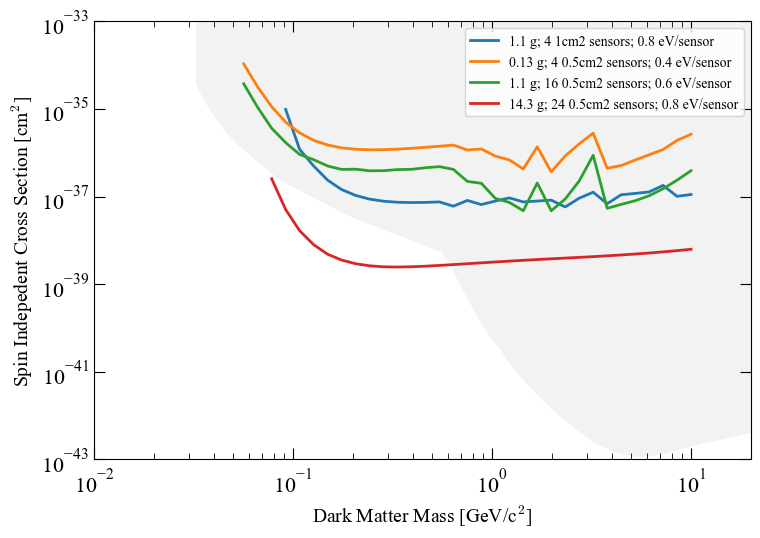

In [8]:
acceptance_cut = 0.001

fig, ax = plt.subplots(figsize=(9, 6))
plotexcludedsi(ax, details=False)
#load_and_plot_existing(ax,leg=False,lw=1.5,leg_params={'loc':'upper right','frameon':False,'handlelength':1.5 } )

leg_hands = []

lab = '{:0.2f} eV thres./sensor'.format(thres*1e3)

# select only point with acceptance greater than cut value
#i = 1
#for j in np.arange(1,3):
#    acc_mask = data['{:d}_{:d}'.format(i,j)][:,2]>acceptance_cut
#    masses = data['{:d}_{:d}'.format(i,j)][:,0][acc_mask]
#    sigs = data['{:d}_{:d}'.format(i,j)][:,1][acc_mask]
#    
#    lh, = plt.plot(masses,sigs,label=lab)#,color='blue')
#    leg_hands.append(lh)

j=1
for i in np.arange(1,5):
    acc_mask = data['{:d}_{:d}'.format(i,j)][:,2]>acceptance_cut
    masses = data['{:d}_{:d}'.format(i,j)][:,0][acc_mask]
    sigs = data['{:d}_{:d}'.format(i,j)][:,1][acc_mask]
    
    lh, = plt.plot(masses,sigs,label=lab)#,color='blue')
    leg_hands.append(lh)

leg_labels = ['1.1 g; 4 1cm2 sensors; 0.8 eV/sensor',
              '0.13 g; 4 0.5cm2 sensors; 0.4 eV/sensor',
              '1.1 g; 16 0.5cm2 sensors; 0.6 eV/sensor',
              '14.3 g; 24 0.5cm2 sensors; 0.8 eV/sensor']

#ax.set_title('{:0.1f} g LHe; {:0.0f} days; {:0.1f} g-day'.format(mass_det*1e3,times[i],mass_det*1e3*times[i]))
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-43, 1e-33)
ax.set_xlim(0.01, 20)
ax.set_xlabel("Dark Matter Mass [GeV/c$^2$]", fontsize=14)
ax.set_ylabel("Spin Indepedent Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

ax.legend(handles=leg_hands,labels=leg_labels,loc='upper right',frameon=True,ncol=1) #,title='{:d} Devices'.format(n_devices)) #bbox_to_anchor=(0.5, 1.05)

In [4]:
# load results from .txt files

acc_cut = 0.1

window = 100e-6 # s
n_sensors = 4
coincidence = 4
nexp = 100
target_mass_kg = 0.001071

#results_dir = 'results-n_sensors{:d}-coincidence{:d}-nexp{:d}'.format(n_sensors,coincidence,nexp)
results_dir = 'results-run57leetest_1e-3keV'

data = {}
data['1_1'] = np.loadtxt('./{:s}/limit.txt'.format(results_dir))

#for i,t in enumerate(times):
#    for j,n in enumerate(coinc):
#        data['{:d}_{:d}'.format(i,j)] = np.loadtxt('./{:s}/HeRALD_FC_{:0.0f}d_{:d}device_{:d}fold_{:0.0f}mus.txt'.format(results_dir,t,n_devices,n,window/1e-6))

In [5]:
data['1_1']

array([[8.00000e-02, 9.63261e-34, 1.03412e-06],
       [1.07195e-01, 3.82283e-37, 3.06804e-03],
       [1.43635e-01, 2.65820e-38, 5.28170e-02],
       [1.92463e-01, 8.42673e-39, 2.01323e-01],
       [2.57888e-01, 5.01257e-39, 4.08757e-01],
       [3.45555e-01, 4.05967e-39, 6.02938e-01],
       [4.63023e-01, 3.86512e-39, 7.45611e-01],
       [6.20423e-01, 3.96788e-39, 8.40200e-01],
       [8.31330e-01, 4.20118e-39, 8.99721e-01],
       [1.11393e+00, 4.50008e-39, 9.35408e-01],
       [1.49260e+00, 4.81796e-39, 9.57894e-01],
       [2.00000e+00, 5.16964e-39, 9.71598e-01]])

/tmp/ipykernel_1710378/355461292.py:16: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)


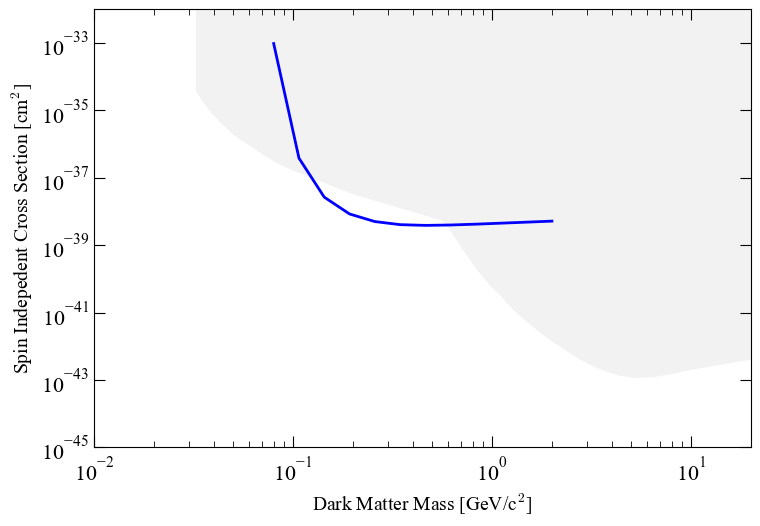

In [7]:
# first plot

fig, ax = plt.subplots(figsize=(9, 6))
plotexcludedsi(ax, details=False)
#load_and_plot_existing(ax,leg=False,lw=1.5,leg_params={'loc':'upper right','frameon':False,'handlelength':1.5 } )

leg_hands = []

lab = '{:d}-fold coinc'.format(coincidence)

# select only point with acceptance greater than cut value
i = 1
j = 1
acc_mask = data['{:d}_{:d}'.format(i,j)][:,2]>0
masses = data['{:d}_{:d}'.format(i,j)][:,0][acc_mask]
sigs = data['{:d}_{:d}'.format(i,j)][:,1][acc_mask]

lh, = plt.plot(masses,sigs,label=lab,color='blue')
leg_hands.append(lh)

    
#ax.set_title('{:0.1f} g LHe; {:0.0f} days; {:0.1f} g-day'.format(mass_det*1e3,times[i],mass_det*1e3*times[i]))
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-45, 1e-32)
ax.set_xlim(0.01, 20)
ax.set_xlabel("Dark Matter Mass [GeV/c$^2$]", fontsize=14)
ax.set_ylabel("Spin Indepedent Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

#ax.legend(handles=leg_hands,loc='upper left',frameon=True,ncol=1,title='{:d} Devices'.format(n_devices)) #bbox_to_anchor=(0.5, 1.05)

3


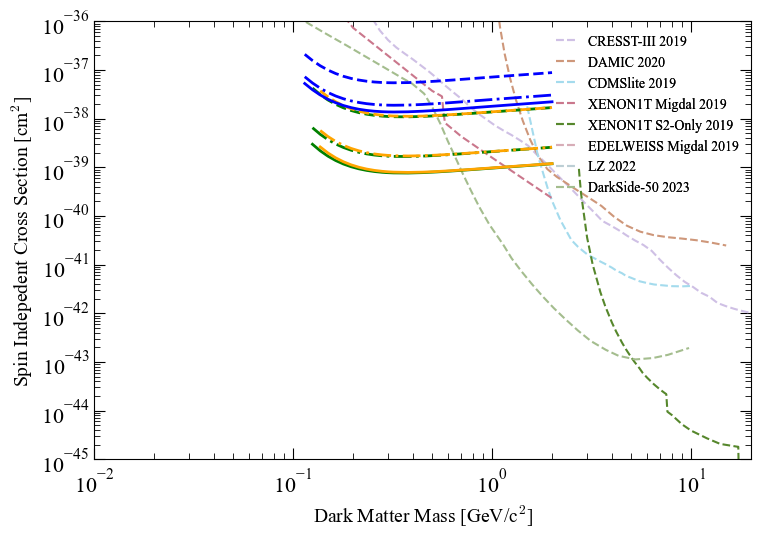

In [78]:
# money plot of sorts... selected run times 

t_sel = np.array([30,183,365])
t_idxs = []
for t in t_sel:
    idx,_ = find_nearest(times, t)
    t_idxs.append(idx)

colors = ['blue','green','orange']

n_lines = len(t_idxs)
print(n_lines)
cmaps = ['Blues','Oranges','Greens']
cmap = mpl.colormaps['Blues']

#colors = cmap(np.linspace(0.5, 1, n_lines))

lss = ['--','-.','-']
    
fig, ax = plt.subplots(figsize=(9, 6))
load_and_plot_existing(ax,leg=True,lw=1.5,leg_params={'loc':'upper right','frameon':False,'handlelength':1.5 } )
for ii,i in enumerate(t_idxs):
    
    leg_hands = []
    for j,n in enumerate(coinc):
        lab = '{:d}-fold coinc in {:0.0f}$\mu$s'.format(n,window/1e-6)
        #lh, = plt.plot(*(data['{:d}_{:d}'.format(i,j)].T), marker='.',ms=5,label=lab,color=colors[j])
        
        acc_mask = data['{:d}_{:d}'.format(i,j)][:,2]>acc_cut
        masses = data['{:d}_{:d}'.format(i,j)][:,0][acc_mask]
        sigs = data['{:d}_{:d}'.format(i,j)][:,1][acc_mask]
        
        lh, = plt.plot(masses,sigs,label=lab,color=colors[j],ls=lss[ii])
        leg_hands.append(lh)
    
#ax.set_title('{:0.1f} g LHe; {:0.0f} days; {:0.1f} g-day'.format(mass_det*1e3,times[i],mass_det*1e3*times[i]))
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-45, 1e-36)
ax.set_xlim(0.01, 20)
ax.set_xlabel("Dark Matter Mass [GeV/c$^2$]", fontsize=14)
ax.set_ylabel("Spin Indepedent Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

#ax.legend(handles=leg_hands,loc='upper left',frameon=True,ncol=1,title='{:d} Devices'.format(n_devices)) #bbox_to_anchor=(0.5, 1.05)

/tmp/ipykernel_960031/355461292.py:16: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)


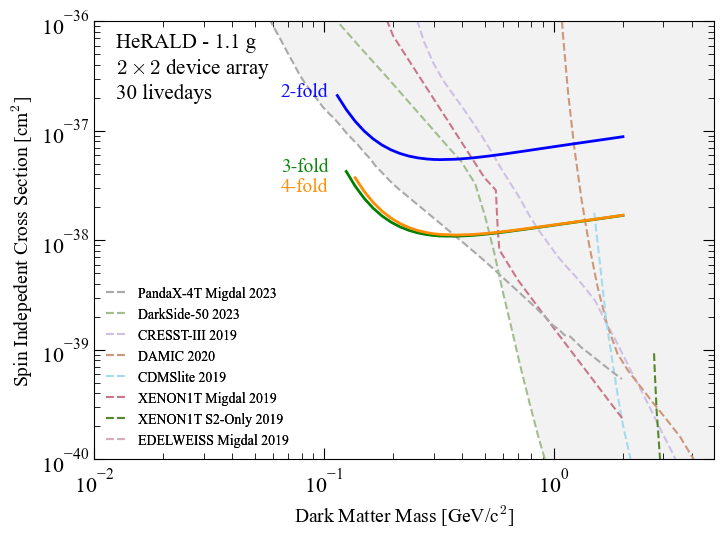

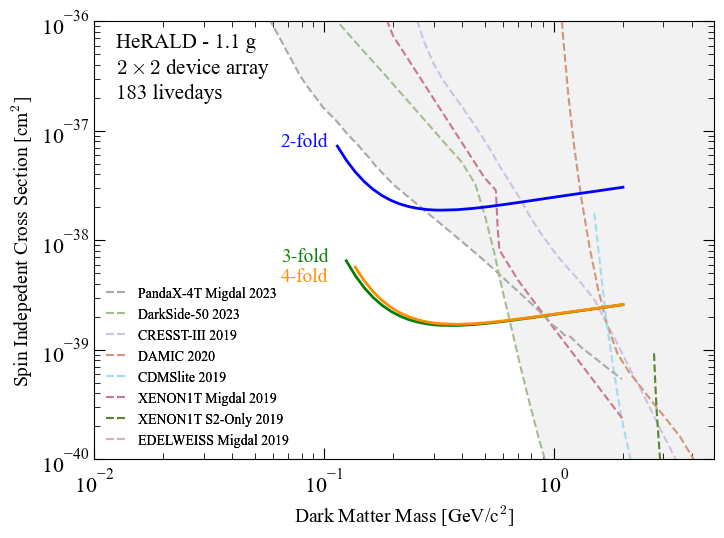

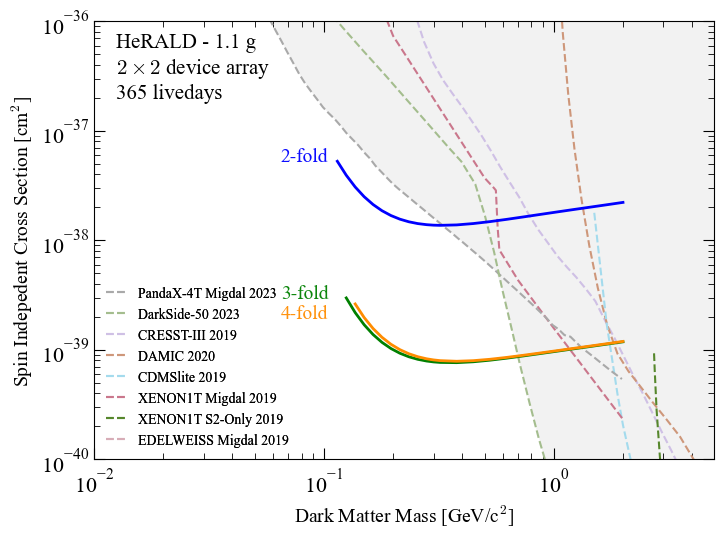

In [164]:
# money plot of sorts... selected run times 

t_sel = np.array([30,183,365])
t_idxs = []
for t in t_sel:
    idx,_ = find_nearest(times, t)
    t_idxs.append(idx)

colors = ['blue','green','darkorange']


lss = ['-','-','-']
    
for ii,i in enumerate(t_idxs):
    
    fig, ax = plt.subplots()
    
    plotexcludedsi(ax, details=False)
    #leg_params = {'loc':'upper right',
    #              'frameon':True,
    #              'handlelength':1.5,
    #              'fontsize':9,
    #              'ncol':3 }
    leg_params = {'loc':'lower left',
                  'frameon':False,
                  'handlelength':1.5,
                  'fontsize':10,
                  'ncol':1 }
    load_and_plot_existing(ax,leg=True,lw=1.5,leg_params=leg_params )
    
    #ax.text(1.3e-2,1.5e-40,'HeRALD - {:0.1f} g \n2x2 device array \n {:0.0f} livedays'.format(mass_det*1e3,times[i]),fontsize=15)
    ax.text(1.25e-2,2e-37,'HeRALD - {:0.1f} g \n'.format(mass_det*1e3)+r'$2\times2$'+' device array \n'+'{:0.0f} livedays'.format(times[i]),fontsize=15)
    
    leg_hands = []
    for j,n in enumerate(coinc):
        #lab = '{:d}-fold coinc in {:0.0f}$\mu$s'.format(n,window/1e-6)
        lab = '{:d}-fold'.format(n)
        
        #lh, = plt.plot(*(data['{:d}_{:d}'.format(i,j)].T), marker='.',ms=5,label=lab,color=colors[j])
        
        acc_mask = data['{:d}_{:d}'.format(i,j)][:,2]>acc_cut
        masses = data['{:d}_{:d}'.format(i,j)][:,0][acc_mask]
        sigs = data['{:d}_{:d}'.format(i,j)][:,1][acc_mask]
        
        lh, = plt.plot(masses,sigs,label=lab,color=colors[j],ls=lss[ii],lw=2)
        #leg_hands.append(lh)
        
        x = 6.5e-2
        if n<4:
            y = sigs[0]
        else: 
            y = sigs[0]*0.75
        ax.text(x,y,lab,fontsize=14,color=colors[j],alpha=0.95)

    ax.set_yscale('log')
    ax.set_xscale('log')

    ax.set_ylim(1e-40, 1e-36)
    ax.set_xlim(0.01, 5)
    ax.set_xlabel("Dark Matter Mass [GeV/c$^2$]", fontsize=14)
    ax.set_ylabel("Spin Indepedent Cross Section [cm$^2$]", fontsize=14)

    #ax.grid(lw=0.3,ls='--',color='grey')
    #ax.grid(which="minor", linestyle='dotted')
    ax.tick_params(which="both", direction="in", right=True, top=True)

    #ax.legend(handles=leg_hands,loc='upper left',frameon=True,ncol=1,title='{:d} Devices'.format(n_devices)) #bbox_to_anchor=(0.5, 1.05)
    
    #plt.savefig('./pretty_plots/herald_limits_{:0.1f}g_{:0.0f}d.png'.format(mass_det*1e3,times[i]),facecolor='white',bbox_inches='tight')

[[0.41708574 0.68063053 0.83823145 1.        ]
 [0.12710496 0.44018454 0.70749712 1.        ]
 [0.03137255 0.18823529 0.41960784 1.        ]]


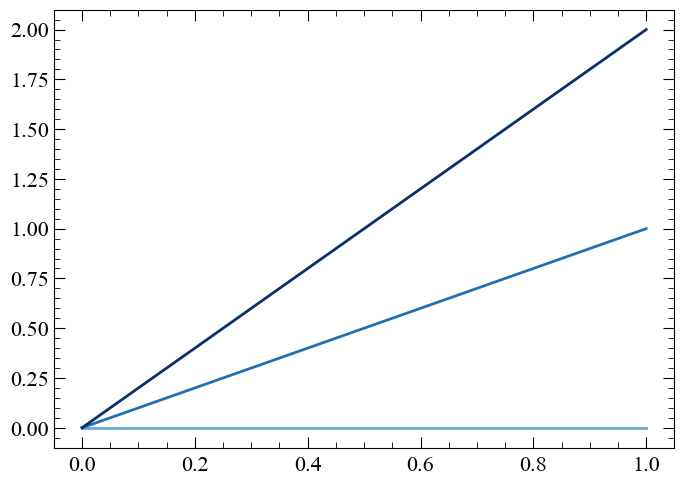

In [36]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib as mpl

n_lines = 3
cmap = mpl.colormaps['Blues']

# Take colors at regular intervals spanning the colormap.
colors = cmap(np.linspace(0.5, 1, n_lines))

print(colors)

fig, ax = plt.subplots()

for i, color in enumerate(colors):
    ax.plot([0, i], color=color)


/tmp/ipykernel_1929283/591399673.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(9, 6))


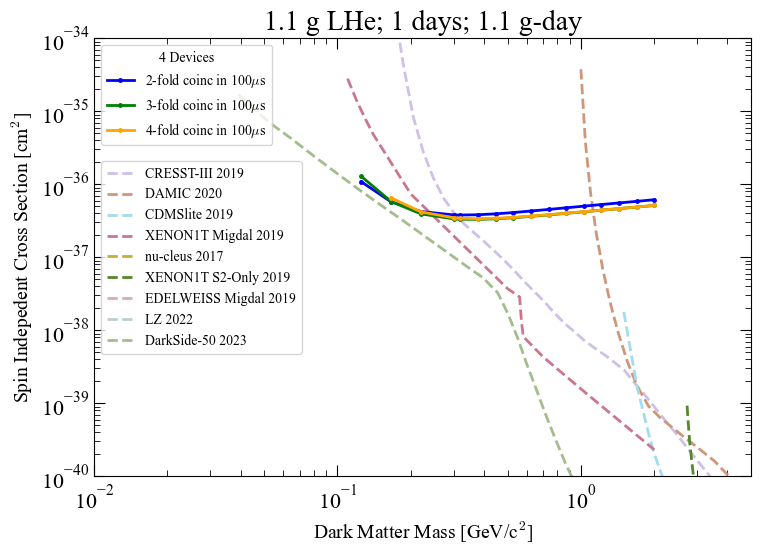

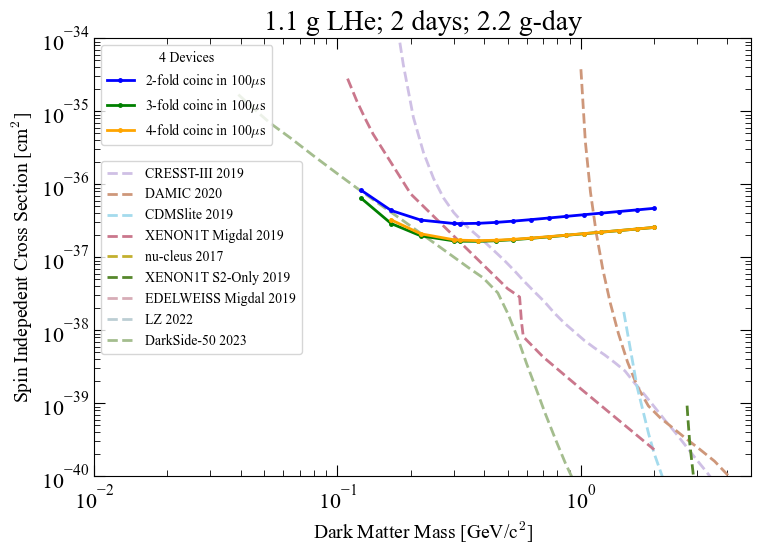

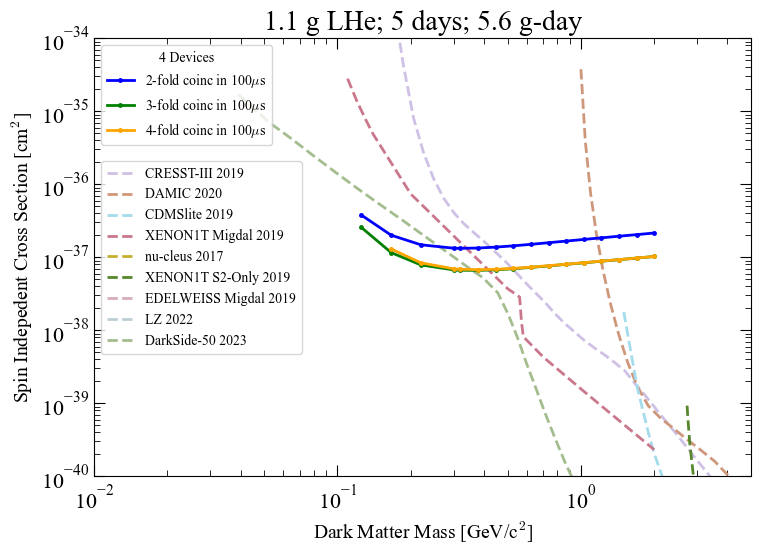

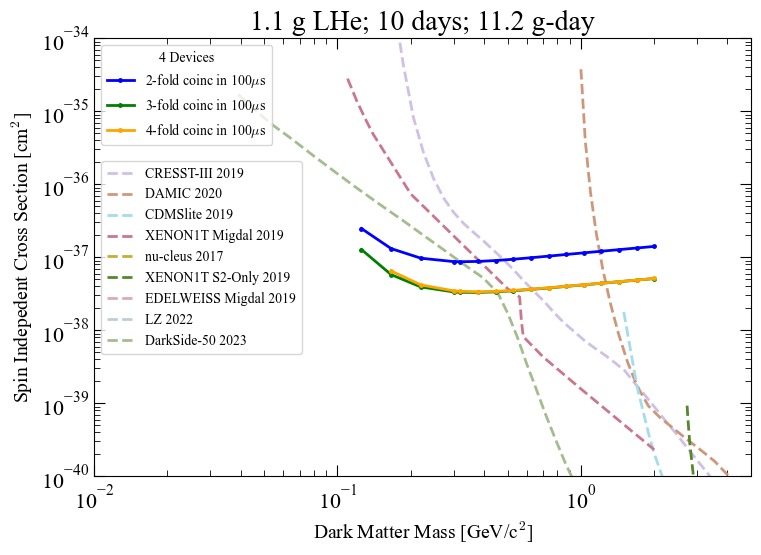

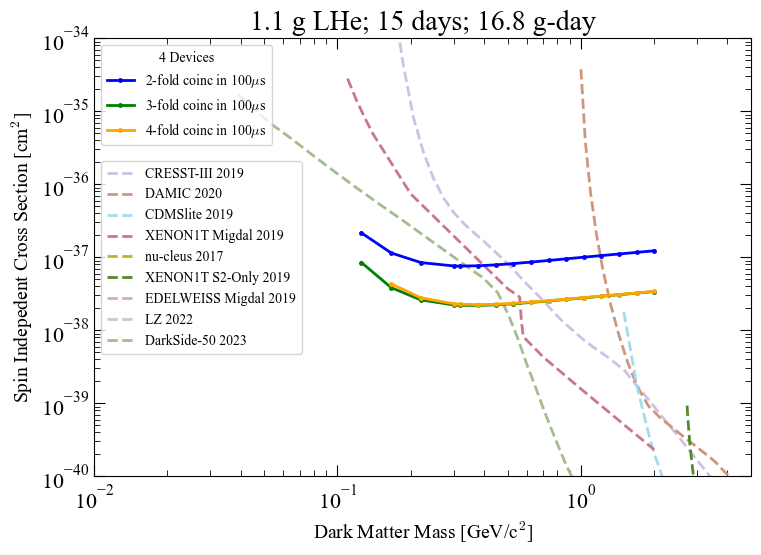

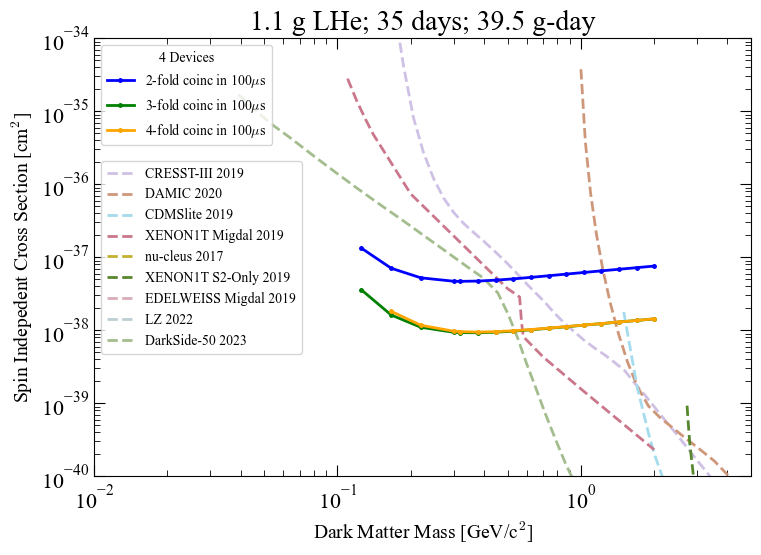

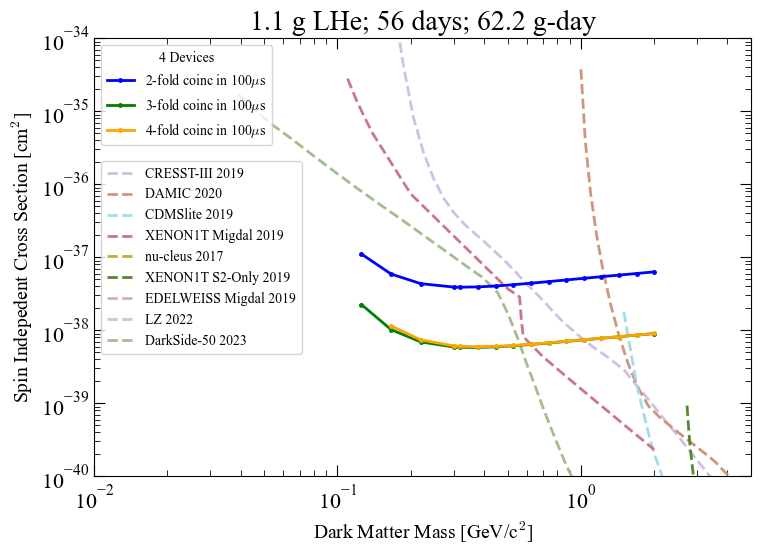

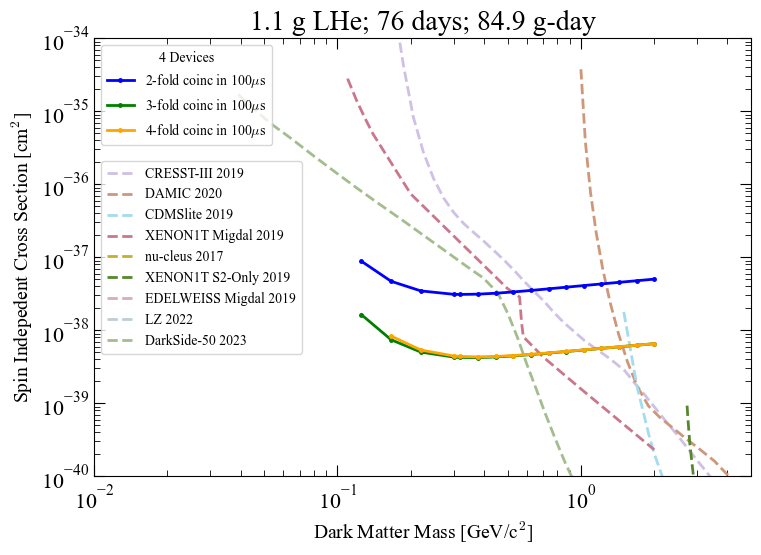

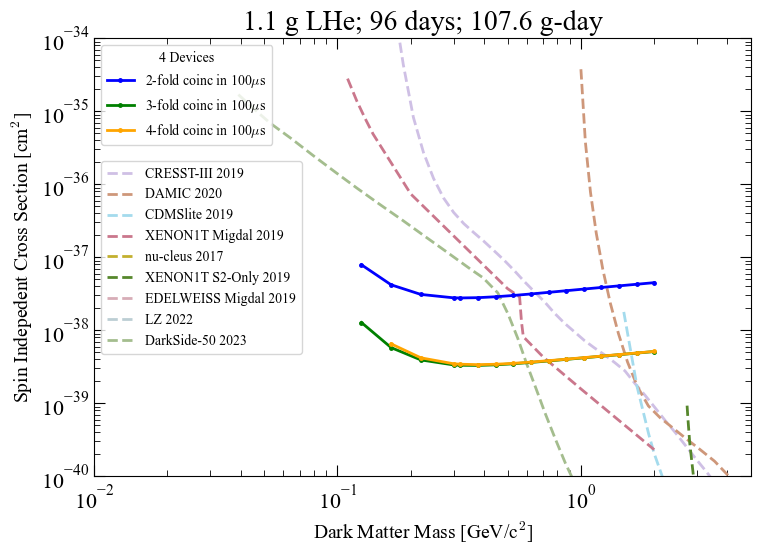

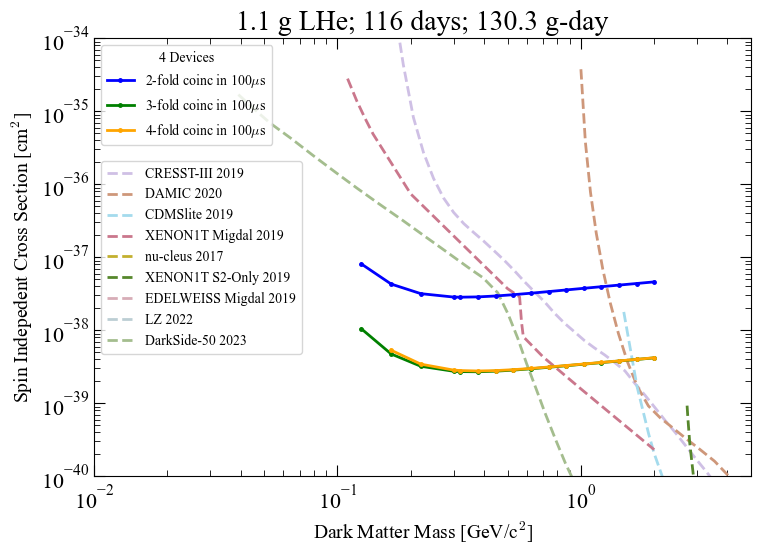

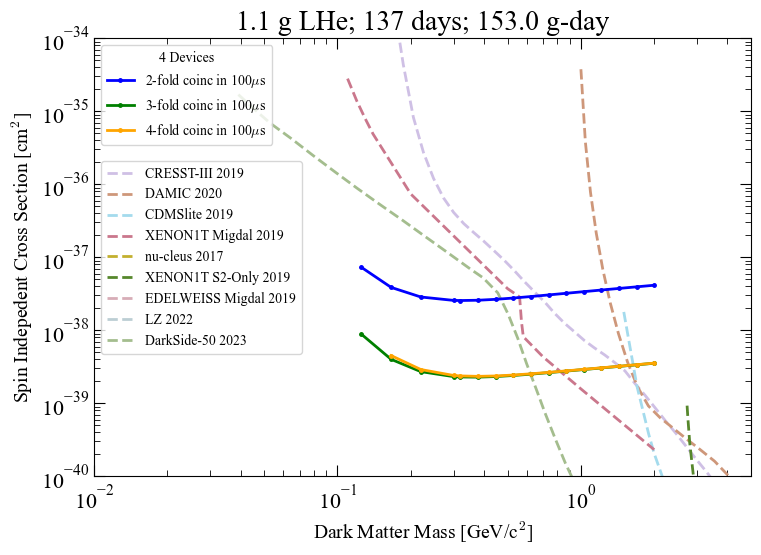

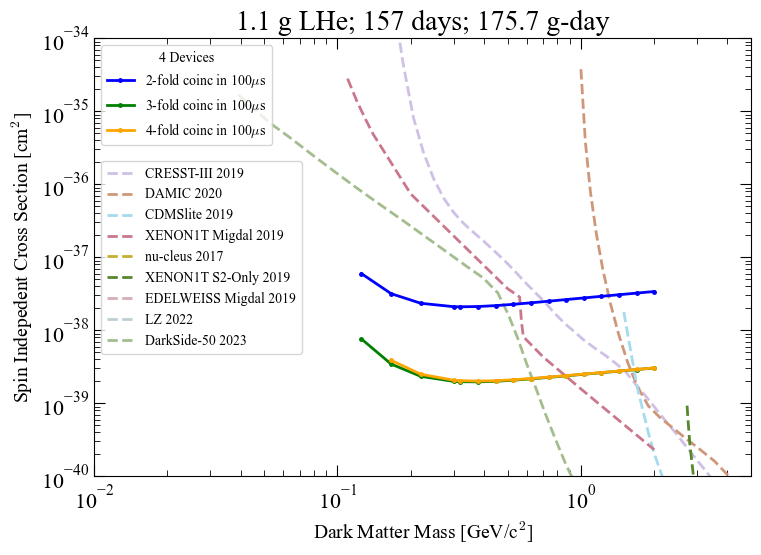

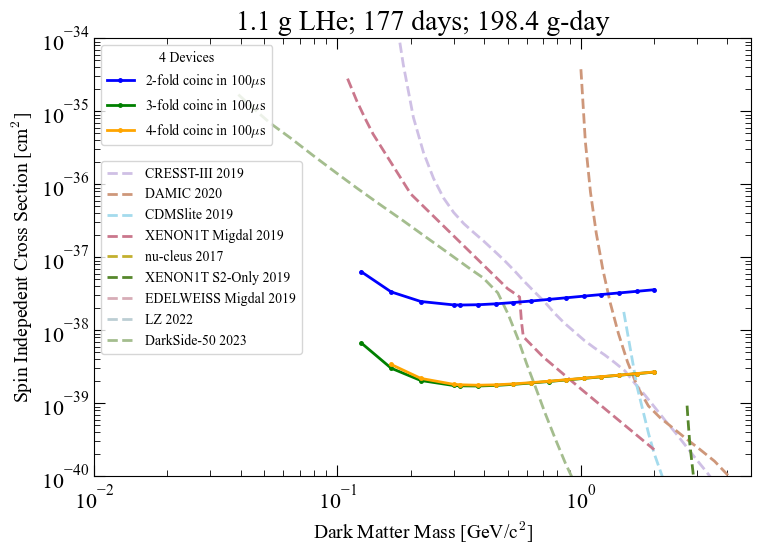

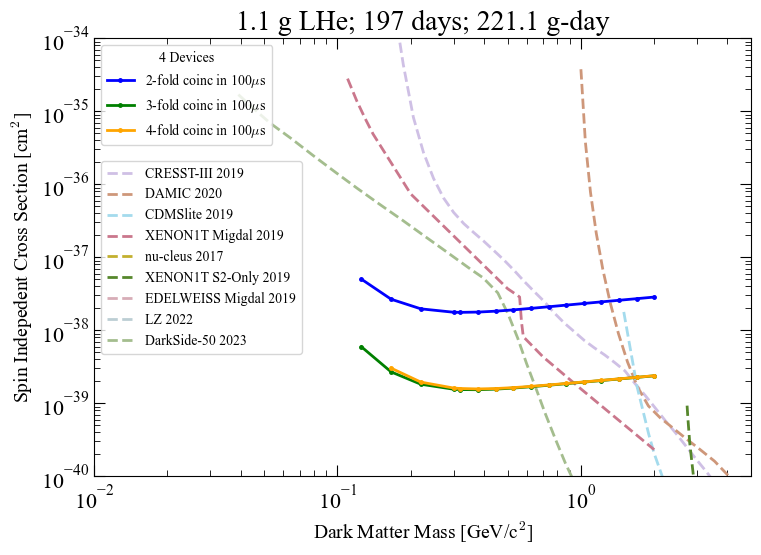

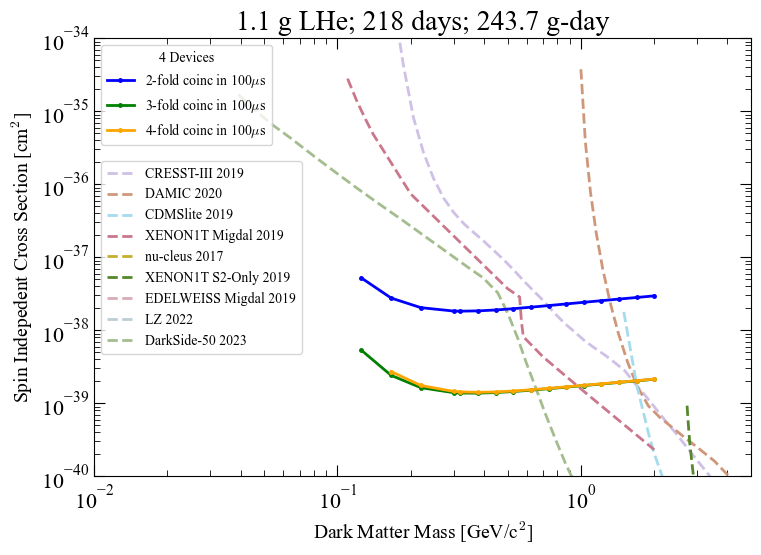

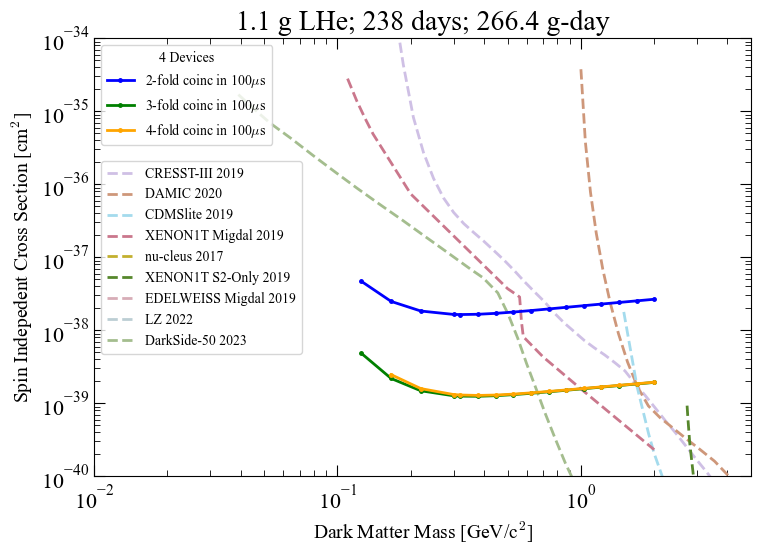

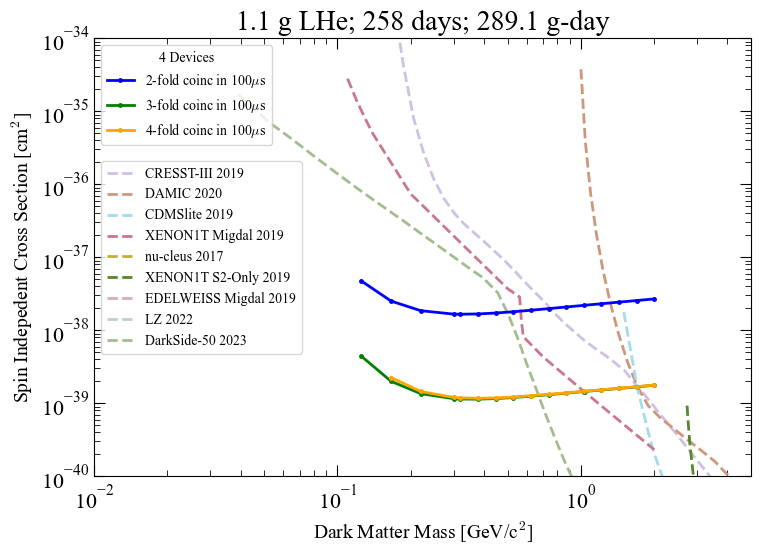

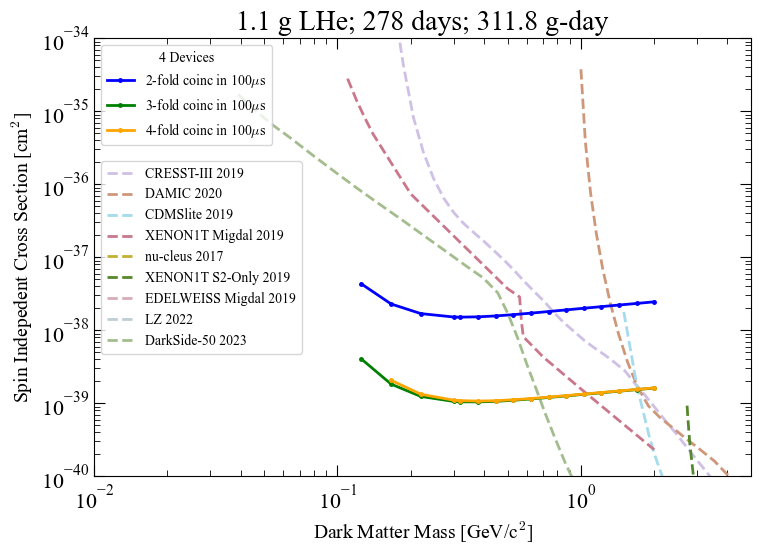

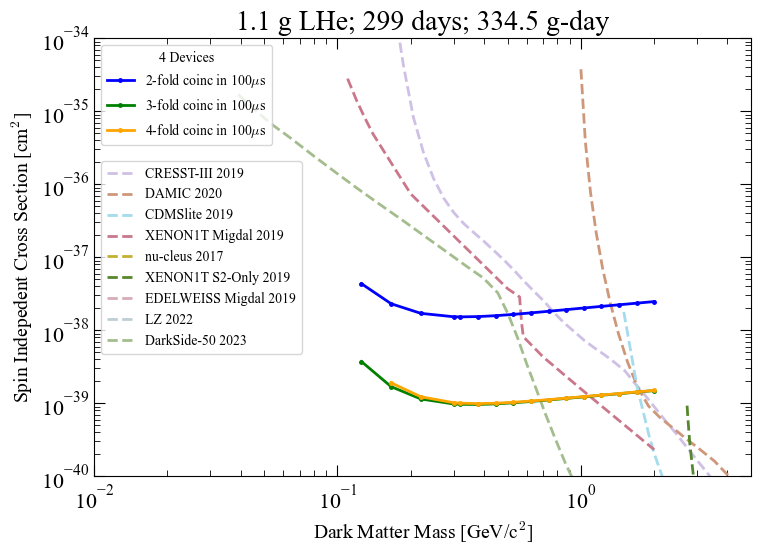

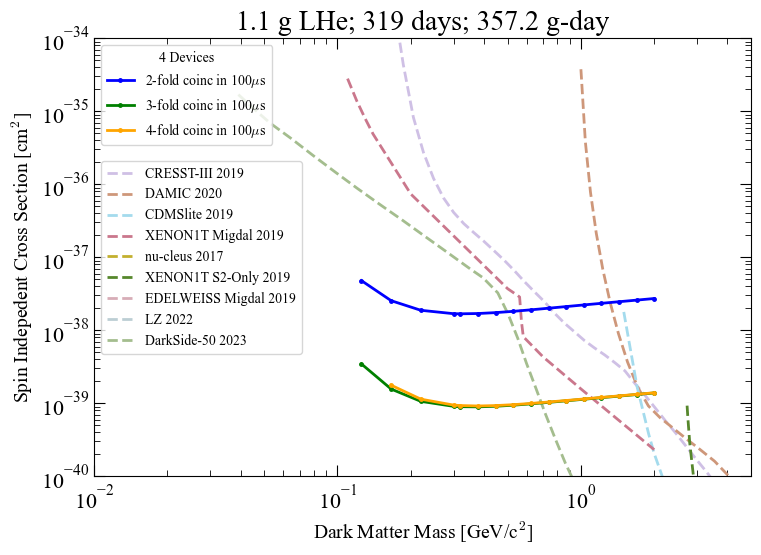

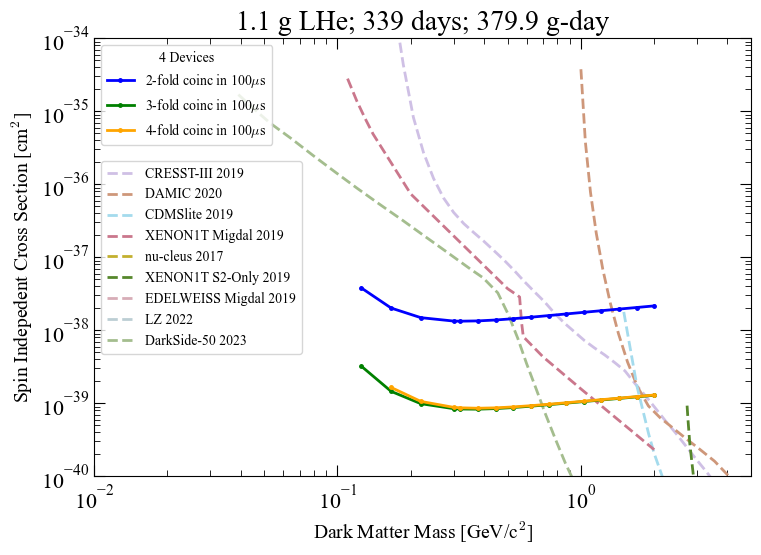

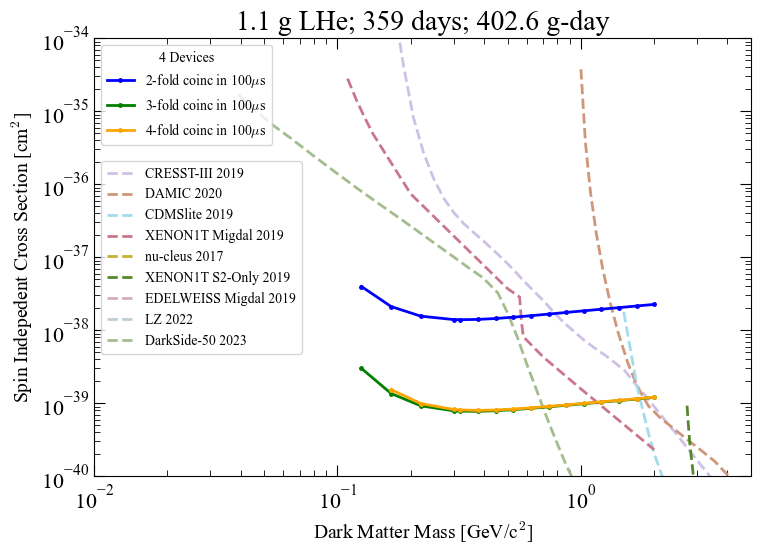

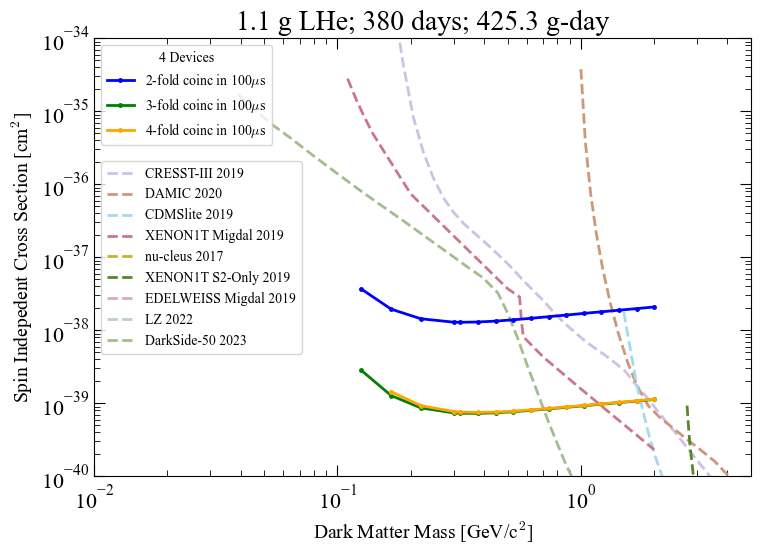

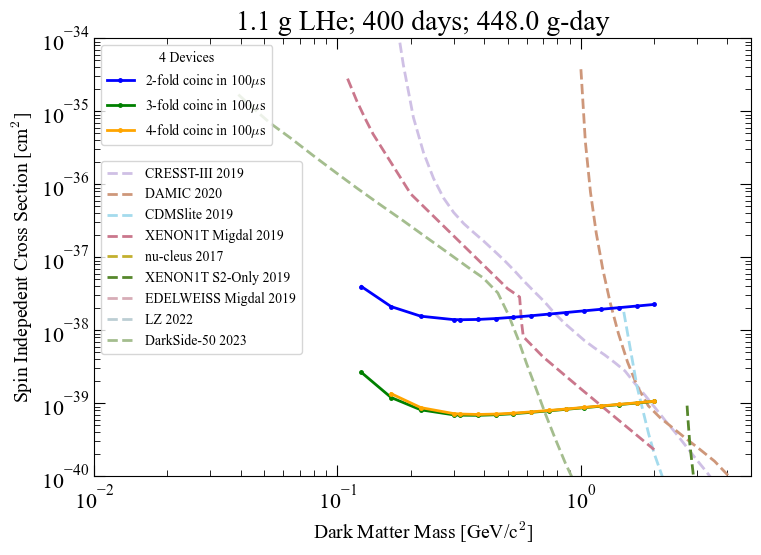

In [21]:
colors = ['blue','green','orange']

for i,t in enumerate(times):
    
    fig, ax = plt.subplots(figsize=(9, 6))
    #plt.plot(*(x1tmig.T),color=(0.,0.6,0.,0.7),ls='--',label='XENON1T Migdal')
    load_and_plot_existing(ax,leg=True,leg_params={'loc':'center left' } ) #,'bbox_to_anchor':(0.1,0.5)
    #fig.subplots_adjust(right=0.6)
    # Shrink current axis by 20%
    #box = ax.get_position()
    #ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

    
    leg_hands = []
    for j,n in enumerate(coinc):
        lab = '{:d}-fold coinc in {:0.0f}$\mu$s'.format(n,window/1e-6)
        #lh, = plt.plot(*(data['{:d}_{:d}'.format(i,j)].T), marker='.',ms=5,label=lab,color=colors[j])
        acc_mask = data['{:d}_{:d}'.format(i,j)][:,2]>acc_cut
        masses = data['{:d}_{:d}'.format(i,j)][:,0][acc_mask]
        sigs = data['{:d}_{:d}'.format(i,j)][:,1][acc_mask]
        lh, = plt.plot(masses,sigs, marker='.',ms=5,label=lab,color=colors[j])
        leg_hands.append(lh)

    ax.set_title('{:0.1f} g LHe; {:0.0f} days; {:0.1f} g-day'.format(mass_det*1e3,times[i],mass_det*1e3*times[i]))
    ax.set_yscale('log')
    ax.set_xscale('log')

    ax.set_ylim(1e-40, 1e-34)
    ax.set_xlim(0.01, 5)
    ax.set_xlabel("Dark Matter Mass [GeV/c$^2$]", fontsize=14)
    ax.set_ylabel("Spin Indepedent Cross Section [cm$^2$]", fontsize=14)
    #ax.set_title("Estimated Sensitivity", fontsize=14)

    #ax.grid(lw=0.3,ls='--',color='grey')
    #ax.grid(which="minor", linestyle='dotted')
    ax.tick_params(which="both", direction="in", right=True, top=True)

    ax.legend(handles=leg_hands,loc='upper left',frameon=True,ncol=1,title='{:d} Devices'.format(n_devices)) #bbox_to_anchor=(0.5, 1.05)
    
    #bbox_extra_artists=(lgd,text)

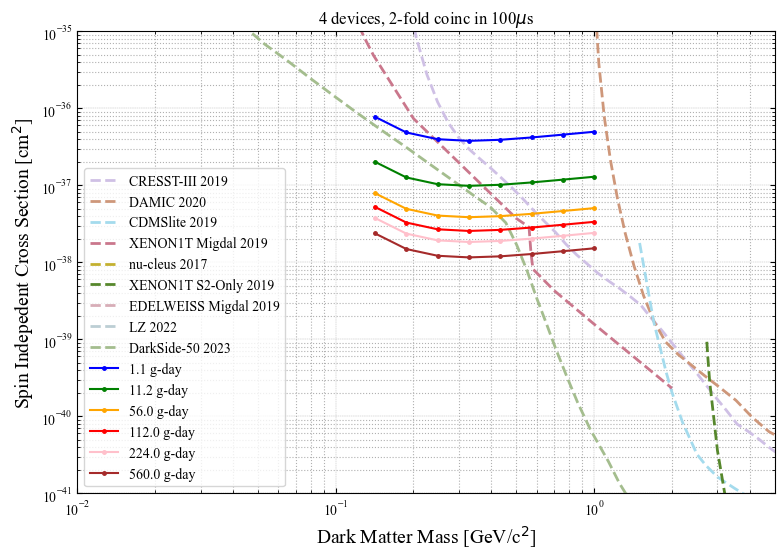

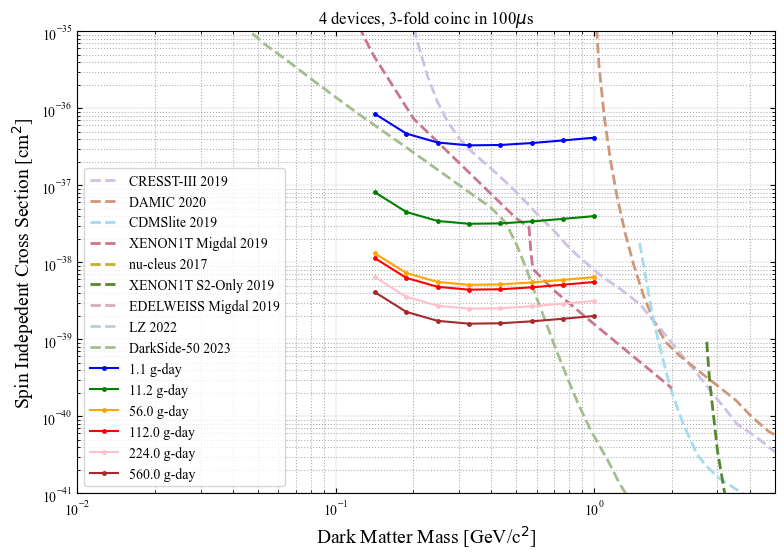

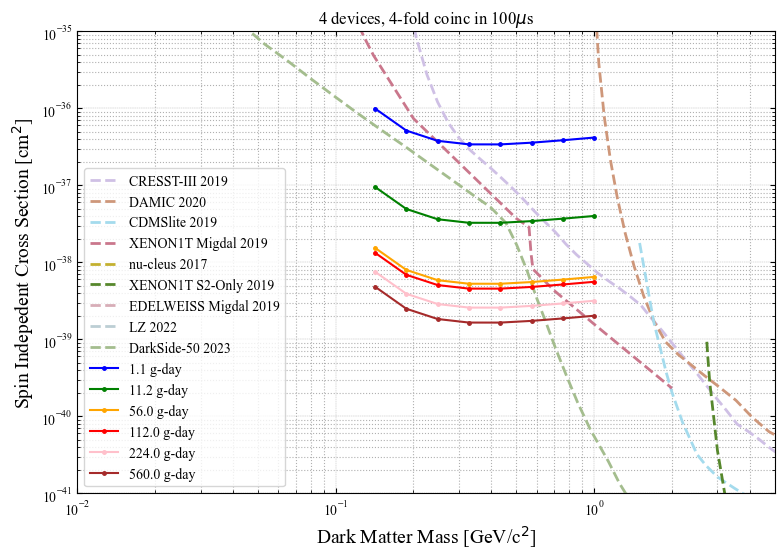

In [5]:
colors = ['blue','green','orange','red','pink','brown']

for j,n in enumerate(coinc):
    
    fig, ax = plt.subplots(figsize=(9, 6))
    #plt.plot(*(x1tmig.T),color=(0.,0.6,0.,0.7),ls='--',label='XENON1T Migdal')
    load_and_plot_existing(ax,leg=False,leg_params={'loc':'center left','bbox_to_anchor':(0.8,0.5) } )
    
    for i,t in enumerate(times):
        #print(coinc[j])
        #lab = '{:0.1f} g-day;\n{:d} devices, {:d}-fold coinc in {:0.0f}$\mu$s'.format(mass_det*1e3*t,n_devices,n,window/1e-6)
        lab = '{:0.1f} g-day'.format(mass_det*1e3*t)
        acc_mask = data['{:d}_{:d}'.format(i,j)][:,2]>acc_cut
        masses = data['{:d}_{:d}'.format(i,j)][:,0][acc_mask]
        sigs = data['{:d}_{:d}'.format(i,j)][:,1][acc_mask]
        plt.plot(masses,sigs, marker='.',ms=5,label=lab,color=colors[i])
    
    title = '{:d} devices, {:d}-fold coinc in {:0.0f}$\mu$s'.format(n_devices,n,window/1e-6)
    ax.set_title(title)
    ax.set_yscale('log')
    ax.set_xscale('log')

    ax.set_ylim(1e-41, 1e-35)
    ax.set_xlim(0.01, 5)
    ax.set_xlabel("Dark Matter Mass [GeV/c$^2$]", fontsize=14)
    ax.set_ylabel("Spin Indepedent Cross Section [cm$^2$]", fontsize=14)
    #ax.set_title("Estimated Sensitivity", fontsize=14)

    ax.grid(lw=0.3,ls='--')
    ax.grid(which="minor", linestyle='dotted')
    ax.tick_params(which="both", direction="in", right=True, top=True)

    ax.legend(loc='lower left',frameon=True)

0.3


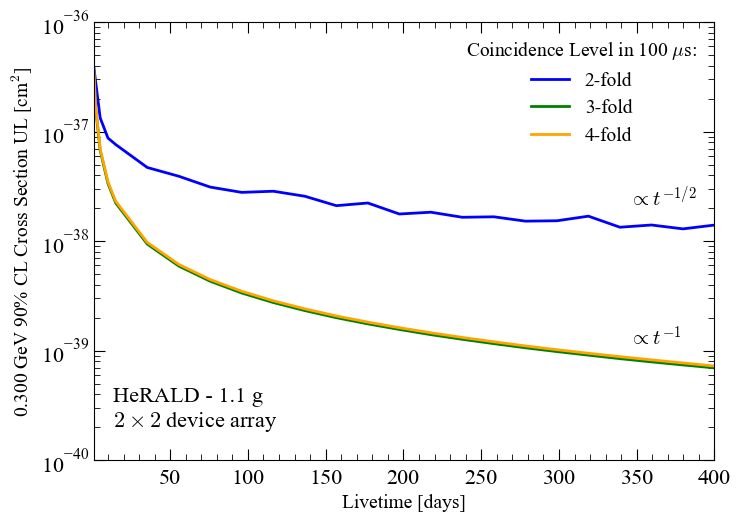

In [139]:

# for fixed DM mass, plot limit vs runtime for each coinc level
m = 0.3 # GeV
m_idx, m = find_nearest(data['0_0'][:,0], m)
print(m)



fig, ax = plt.subplots()

leg_hands = []
for j,n in enumerate(coinc):
#for j,n in enumerate([4]):
    
    sigs = np.zeros(len(times))
    for i,t in enumerate(times):
        sigs[i] = data['{:d}_{:d}'.format(i,j)][m_idx,1]
    
    # find times to avoid FC jumps
    #slope_mask = np.diff(sigs)<0
    #print(slope_mask)
    #slope_mask = np.insert(slope_mask,0,1) #add True to make len equal
    #print(len(slope_mask))
    
    tmask = np.ones(len(times), dtype=bool)
    tmask[[5,14,24]] = False
    thetimes = times[tmask]
    thesigs = sigs[tmask]
    
    lab = '{:d}-fold'.format(n)
    lh, = plt.plot(thetimes,thesigs, label=lab,lw=2, color=colors[j])
    
    #plt.plot(times[slope_mask],sigs[slope_mask], marker='.',ms=7,label=lab,ls='')#,color=colors[j])
    
    leg_hands.append(lh)

ts = np.linspace(50,500,500)
#plt.plot(ts,3.5e-37*ts**(-0.5),ls='--',lw=0.5,color='black')
ax.text(345,2.1e-38,r'$\propto t^{-1/2}$',fontsize=15)

ts2 = np.linspace(1,500,500)
#plt.plot(ts2,4e-37*ts2**(-1),ls='--',lw=0.5,color='black')
ax.text(345,1.1e-39,r'$\propto t^{-1}$',fontsize=15)

#ax.set_title('{:0.1f} grams LHe'.format(mass_det*1e3))
ax.set_yscale('log')
#ax.set_xscale('log')

ax.set_ylim(1e-40, 1e-36)
ax.set_xlim(times[0],400)
ax.set_xlabel("Livetime [days]", fontsize=14)
ax.set_ylabel(r'{:0.3f} GeV 90% CL Cross Section UL [cm$^2$]'.format(m), fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

ax.legend(handles=leg_hands,loc='upper right',frameon=False,ncol=1,
          title='Coincidence Level in {:0.0f} $\mu$s:'.format(window/1e-6),
          fontsize=14,
          title_fontsize=14
         ) #bbox_to_anchor=(0.5, 1.05)

#bbox_extra_artists=(lgd,text)

ax.text(13,2e-40,'HeRALD - {:0.1f} g \n'.format(mass_det*1e3)+r'$2\times2$'+' device array',fontsize=16)

plt.savefig('./pretty_plots/herald_{:0.3f}GeV_limit_vs_time_{:0.1f}g_{:0.0f}d.png'.format(m,mass_det*1e3,times[i]),facecolor='white',bbox_inches='tight')



In [115]:
tmask = np.ones(len(times), dtype=bool)
tmask[[5,14,24]] = False
times[tmask]

array([  1.        ,   2.        ,   5.        ,  10.        ,
        15.        ,  35.26315789,  55.52631579,  75.78947368,
        96.05263158, 116.31578947, 136.57894737, 156.84210526,
       177.10526316, 197.36842105, 217.63157895, 237.89473684,
       258.15789474, 278.42105263, 298.68421053, 318.94736842,
       339.21052632, 359.47368421, 379.73684211, 400.        ])

In [114]:
times

array([  1.        ,   2.        ,   5.        ,  10.        ,
        15.        ,  30.        ,  35.26315789,  55.52631579,
        75.78947368,  96.05263158, 116.31578947, 136.57894737,
       156.84210526, 177.10526316, 183.        , 197.36842105,
       217.63157895, 237.89473684, 258.15789474, 278.42105263,
       298.68421053, 318.94736842, 339.21052632, 359.47368421,
       365.        , 379.73684211, 400.        ])

In [22]:
for k, s in sigs:
    if k!=(len(sigs)-1):
        
    

print(np.diff( sigs ))
print( np.diff(sigs)<0 )

[-3.181632e-37 -1.446000e-38 -5.093840e-39 -2.622650e-39 -1.579790e-39
  3.216300e-39 -1.365120e-39 -1.036260e-39 -8.008900e-40 -6.354800e-40
 -5.148000e-40 -4.240400e-40 -3.592800e-40 -2.986300e-40  1.039740e-39
 -3.329600e-40 -2.900100e-40 -2.579600e-40 -2.309400e-40]
[ True  True  True  True  True False  True  True  True  True  True  True
  True  True False  True  True  True  True]


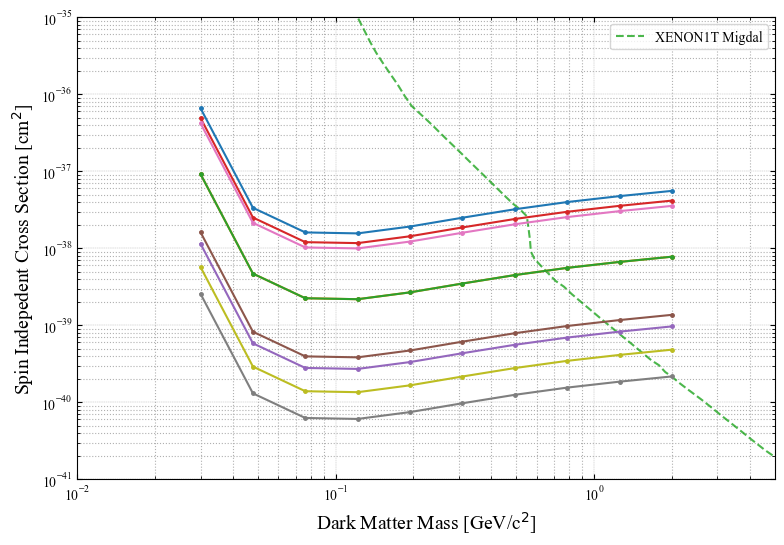

In [5]:

fig, ax = plt.subplots(figsize=(9, 6))

x1tmig = np.loadtxt('/global/cfs/cdirs/lz/users/haselsco/TESSERACT_Limits/snowmass2021-wp-cf1-neutrinofloor/data/published/SI/XENON1T-Migdal.txt')
#cresst = np.loadtxt('/global/cfs/cdirs/lz/users/haselsco/TESSERACT_Limits/snowmass2021-wp-cf1-neutrinofloor/data/published/SI/CRESST.txt')

plt.plot(*(x1tmig.T),color=(0.,0.6,0.,0.7),ls='--',label='XENON1T Migdal')
#plt.plot(*(cresst.T),color=(0.8,0.1,0.1,0.7),label='CRESST')

for i,t in enumerate(exposures):
    for j,n in enumerate(coinc):
    
        #lab = 'HeRALD {:0.3f} kg-day;\n{:d} devices, {:d}-fold coinc in {:0.0f}$\mu$s'.format(SE.exposure,n_devices,coinc,window/1e-6)
        plt.plot(*(data['{:d}_{:d}'.format(i,j)].T), marker='.',ms=5)#,label=lab)

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-41, 1e-35)
ax.set_xlim(0.01, 5)
ax.set_xlabel("Dark Matter Mass [GeV/c$^2$]", fontsize=14)
ax.set_ylabel("Spin Indepedent Cross Section [cm$^2$]", fontsize=14)
#ax.set_title("Estimated Sensitivity", fontsize=14)

ax.grid(lw=0.3,ls='--')
ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

ax.legend(loc='upper right',frameon=True)